# 기본환경 설정

In [32]:
import os, zipfile, urllib.request, math
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [33]:
# 하이퍼파라미터
seq_len     = 24       # LSTM 입력 길이(과거 24시간)
batch_size  = 32
hidden_dim  = 64
num_layers  = 3
dropout     = 0.3
lr          = 1e-4
epochs      = 30

In [34]:
# 특성/타깃 선택
feature_cols = ["T", "RH", "AH", "PT08.S5(O3)", "NO2(GT)", "NO2(GT)", "PT08.S3(NOx)"] # 입력에 쓸 컬럼 (온도, 상대습고, 절대습도)
target_col   = "T" # 다음 시점 예측할 컬럼

* UCI Air Quality 데이터 : 이탈리아의 한 도시 도로변(오염이 심한 지역)에 설치된 가스 멀티센서 장치에서 매 시각(hourly) 평균값을 수집한 시계열 데이터

In [35]:
# 데이터 경로/URL
DATA_URL  = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"
DATA_DIR  = "data/data_airquality"
ZIP_PATH  = os.path.join(DATA_DIR, "AirQualityUCI.zip")
CSV_PATH  = os.path.join(DATA_DIR, "AirQualityUCI.csv")

In [36]:
# 장치 선택 — GPU가 있으면 GPU, 없으면 CPU
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device("cpu")
device

device(type='cuda')

# Data Loading

In [37]:
os.makedirs(DATA_DIR, exist_ok=True)

In [38]:
if not os.path.exists(CSV_PATH):
    print("[INFO] Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        with zf.open("AirQualityUCI.csv") as f, open(CSV_PATH, "wb") as out:
            out.write(f.read())
    print(f"[INFO] Saved: {CSV_PATH}")
else:
    print("[INFO] CSV already exists:", CSV_PATH)

[INFO] CSV already exists: data/data_airquality/AirQualityUCI.csv


In [39]:
# UCI 파일은 세미콜론(;) 구분, 소수점 ,(comma), -200은 결측치 코드
df = pd.read_csv(
    CSV_PATH,
    sep=";",
    decimal=",",
    na_values=-200,
    dtype={"Date": "string", "Time": "string"},
    low_memory=False,
)

In [40]:
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
datetime = df["Date"].str.strip() + " " + df["Time"].str.strip()
df["datetime"] = pd.to_datetime(datetime, format="%d/%m/%Y %H.%M.%S")

In [42]:
df.drop(columns=["Date", "Time"], inplace=True)
df.sort_values("datetime", inplace=True)

# 전처리

In [43]:
# 전부 NaN인 컬럼 제거(파일 끝의 빈 컬럼 등)
df = df.dropna(axis=1, how="all")

In [44]:
# 결측치 처리(-200 -> NaN) 후 시계열 보간
df = df.replace(-200, np.nan).sort_values("datetime").reset_index(drop=True)
df = df.ffill().bfill() # 각 컬럼별로 앞/뒤 값 복사(fill) 방식

In [45]:
# 인덱스 설정
df = df.set_index("datetime")

* UCI Air Quality 데이터
    - Date (형식 DD/MM/YYYY)
    - Time (형식 HH.MM.SS)
    - CO(GT) – 기준 분석기로 측정한 CO 시평균 농도 (mg/m^3)
    - PT08.S1(CO) – 센서 응답(주 대상: CO)
    - NMHC(GT) – 기준 분석기 NMHC(비메탄 탄화수소) (µg/m^3)
    - C6H6(GT) – 기준 분석기 벤젠 (µg/m^3)
    - PT08.S2(NMHC) – 센서 응답(주 대상: NMHC)
    - NOx(GT) – 기준 분석기 NOx (ppb)
    - PT08.S3(NOx) – 센서 응답(주 대상: NOx)
    - NO2(GT) – 기준 분석기 NO2 (µg/m^3)
    - PT08.S4(NO2) – 센서 응답(주 대상: NO2)
    - PT08.S5(O3) – 센서 응답(주 대상: O3)
    - T – 온도 (°C)
    - RH – 상대습도 (%)
    - AH – 절대습도

In [46]:
# 사용 컬럼 미리 확인
df[feature_cols + [target_col]].head(3)

,T,RH,AH,PT08.S5(O3),NO2(GT),NO2(GT),PT08.S3(NOx),T
datetime,,,,,,,,
2004-03-10 18:00:00,13.6,48.9,0.7578,1268.0,113.0,113.0,1056.0,13.6
2004-03-10 19:00:00,13.3,47.7,0.7255,972.0,92.0,92.0,1174.0,13.3
2004-03-10 20:00:00,11.9,54.0,0.7502,1074.0,114.0,114.0,1140.0,11.9


# 학습 데이터 생성

In [47]:
# 다음 시점 예측(horizon=1)
horizon = 1
data = df[sorted(set(feature_cols + [target_col]))].copy()
data["target"] = data[target_col].shift(-horizon)
data = data.dropna().reset_index(drop=False)  # 끝부분 NaN 제거

In [48]:
data

,datetime,AH,NO2(GT),PT08.S3(NOx),PT08.S5(O3),RH,T,target
0,2004-03-10 18:00:00,0.7578,113.0,1056.0,1268.0,48.9,13.6,13.3
1,2004-03-10 19:00:00,0.7255,92.0,1174.0,972.0,47.7,13.3,11.9
2,2004-03-10 20:00:00,0.7502,114.0,1140.0,1074.0,54.0,11.9,11.0
3,2004-03-10 21:00:00,0.7867,122.0,1092.0,1203.0,60.0,11.0,11.2
4,2004-03-10 22:00:00,0.7888,116.0,1205.0,1110.0,59.6,11.2,11.2
...,...,...,...,...,...,...,...,...
9465,2005-04-04 14:00:00,0.5028,168.0,654.0,816.0,13.1,28.5,28.5
9466,2005-04-04 14:00:00,0.5028,168.0,654.0,816.0,13.1,28.5,28.5
9467,2005-04-04 14:00:00,0.5028,168.0,654.0,816.0,13.1,28.5,28.5
9468,2005-04-04 14:00:00,0.5028,168.0,654.0,816.0,13.1,28.5,28.5


## 학습, 검증, 테스트 데이터 분리

In [49]:
N = len(data)
n_train = int(N * 0.7)
n_val   = int(N * 0.1)
n_test  = N - n_train - n_val
n_train, n_val, n_test

(6629, 947, 1894)

In [50]:
train_df = data.iloc[:n_train]
val_df   = data.iloc[n_train:n_train+n_val]
test_df  = data.iloc[n_train+n_val:]

In [51]:
X_train = train_df[feature_cols].values
X_val   = val_df[feature_cols].values
X_test  = test_df[feature_cols].values

In [52]:
y_train = train_df["target"].values.reshape(-1, 1)
y_val   = val_df["target"].values.reshape(-1, 1)
y_test  = test_df["target"].values.reshape(-1, 1)

## 표준화

In [53]:
# 표준화(훈련셋 기준)
x_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(y_train)

In [54]:
X_train_s = x_scaler.transform(X_train)
X_val_s   = x_scaler.transform(X_val)
X_test_s  = x_scaler.transform(X_test)

In [55]:
y_train_s = y_scaler.transform(y_train)
y_val_s   = y_scaler.transform(y_val)
y_test_s  = y_scaler.transform(y_test)

In [56]:
X_train_s.shape, y_train_s.shape, X_val_s.shape, y_val_s.shape, X_test_s.shape, y_test_s.shape

((6629, 7), (6629, 1), (947, 7), (947, 1), (1894, 7), (1894, 1))

## Dataset 생성

In [57]:
class SeqDataset(Dataset):
    """ (seq_len, features) 윈도우 -> 다음 시점 타깃 """
    def __init__(self, X, y, seq_len=24):
        self.X = X
        self.y = y
        self.seq_len = seq_len
        self.idxs = [(i-seq_len, i) for i in range(seq_len, len(X))]

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, i):
        s, e = self.idxs[i]
        x = self.X[s:e]         # (L, F)
        y = self.y[e]           # (1,)
        return torch.from_numpy(x).float(), torch.from_numpy(y).float()

In [58]:
train_ds = SeqDataset(X_train_s, y_train_s, seq_len=seq_len)
val_ds   = SeqDataset(X_val_s,   y_val_s,   seq_len=seq_len)
test_ds  = SeqDataset(X_test_s,  y_test_s,  seq_len=seq_len)

In [59]:
len(train_ds), len(val_ds), len(test_ds)

(6605, 923, 1870)

## Dataloader 생성

In [60]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

In [61]:
next(iter(train_loader))[0].shape  # (batch, seq_len, features)

torch.Size([32, 24, 7])

# 모델 생성

In [63]:
pip install torchinfo

In [64]:
from torchinfo import summary

In [65]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=3, dropout=0.2):
        super().__init__()
        """
        * num_layers 2를 tensorflow로 구현
        inputs = layers.Input(shape=(seq_len, input_size))
        x = layers.LSTM(hidden_size, return_sequences=True, dropout=0.0, recurrent_dropout=0.0)(inputs)
        x = layers.LSTM(hidden_size, return_sequences=True, dropout=0.0, recurrent_dropout=0.0)(x)
        """
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True # True이면 입력/출력의 형태가 (batch, seq_len, feature), False(기본값)이면 (seq_len, batch, feature)
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (B, L, F)
        out, _ = self.lstm(x)
        last = out[:, -1, :]          # 마지막 타임스텝
        yhat = self.fc(last)          # (B, 1)
        return yhat

In [66]:
model = LSTMRegressor(
    input_dim=len(feature_cols),
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=dropout
).to(device)

In [67]:
model

LSTMRegressor(
  (lstm): LSTM(7, 64, num_layers=3, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [68]:
summary(model, input_size=(1, seq_len, len(feature_cols)))

Layer (type:depth-idx)                   Output Shape              Param #
LSTMRegressor                            [1, 1]                    --
├─LSTM: 1-1                              [1, 24, 64]               85,248
├─Linear: 1-2                            [1, 1]                    65
Total params: 85,313
Trainable params: 85,313
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.05
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.34
Estimated Total Size (MB): 0.35

In [69]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

# 학습

In [70]:
best_val = float("inf")
best_state = None

In [71]:
for epoch in range(1, epochs + 1):
    # train
    model.train()
    train_loss_sum, n_train_samples = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * xb.size(0)
        n_train_samples += xb.size(0)
    train_mse = train_loss_sum / n_train_samples

    # val
    model.eval()
    with torch.no_grad():
        val_loss_sum, n_val_samples = 0.0, 0
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            val_loss_sum += loss.item() * xb.size(0)
            n_val_samples += xb.size(0)
        val_mse = val_loss_sum / n_val_samples

    if val_mse < best_val:
        best_val = val_mse
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f"[{epoch:03d}] train_mse={train_mse:.5f}  val_mse={val_mse:.5f}")

# 베스트 가중치 복원
if best_state is not None:
    model.load_state_dict(best_state)

[001] train_mse=0.70629  val_mse=0.25788
[002] train_mse=0.39843  val_mse=0.20260
[003] train_mse=0.31428  val_mse=0.11250
[004] train_mse=0.13642  val_mse=0.08168
[005] train_mse=0.10599  val_mse=0.08015
[006] train_mse=0.09465  val_mse=0.06553
[007] train_mse=0.09119  val_mse=0.06295
[008] train_mse=0.08652  val_mse=0.08573
[009] train_mse=0.08360  val_mse=0.06962
[010] train_mse=0.08166  val_mse=0.06266
[011] train_mse=0.07855  val_mse=0.05414
[012] train_mse=0.07529  val_mse=0.05170
[013] train_mse=0.07487  val_mse=0.05105
[014] train_mse=0.07303  val_mse=0.05078
[015] train_mse=0.07140  val_mse=0.04698
[016] train_mse=0.07061  val_mse=0.04723
[017] train_mse=0.06895  val_mse=0.04601
[018] train_mse=0.07026  val_mse=0.04759
[019] train_mse=0.06852  val_mse=0.05648
[020] train_mse=0.06523  val_mse=0.05124
[021] train_mse=0.06442  val_mse=0.04751
[022] train_mse=0.06305  val_mse=0.04850
[023] train_mse=0.06262  val_mse=0.04132
[024] train_mse=0.06193  val_mse=0.04150
[025] train_mse=

# 테스트 데이터 검증

In [72]:
model.eval()
preds_s, trues_s = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        preds_s.append(pred)
        trues_s.append(yb.numpy())

In [73]:
preds_s = np.vstack(preds_s)
trues_s = np.vstack(trues_s)

In [74]:
# 역변환(표준화 복원)
preds = y_scaler.inverse_transform(preds_s)
trues = y_scaler.inverse_transform(trues_s)

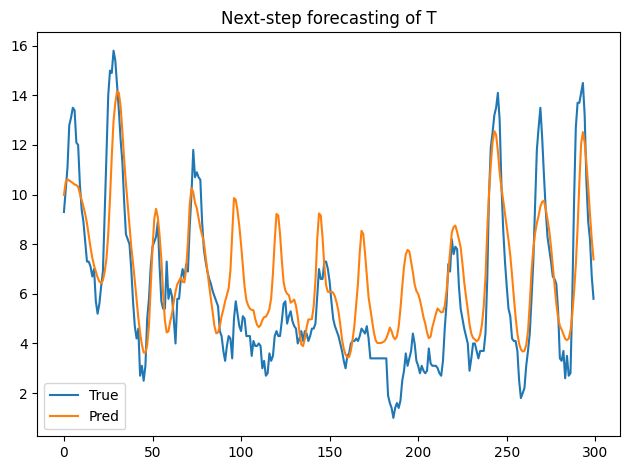

In [75]:
# 앞부분 200개만 그려보기
n_show = min(300, len(preds))
plt.figure()
plt.plot(trues[:n_show], label="True")
plt.plot(preds[:n_show], label="Pred")
plt.title(f"Next-step forecasting of {target_col}")
plt.legend()
plt.tight_layout()
plt.show()

# 예측

In [76]:
# 신규데이터
idx = -20
df_part = test_df.iloc[idx-24:idx][feature_cols]
part_next = df.iloc[idx+1][feature_cols]
part_next

,2005-04-04 14:00:00
T,28.5000
RH,13.1000
AH,0.5028
PT08.S5(O3),816.0000
NO2(GT),168.0000
NO2(GT),168.0000
PT08.S3(NOx),654.0000


In [77]:
def predict(data):
    data_tensor = torch.from_numpy(data).unsqueeze(0).to(device, dtype=torch.float32)
    with torch.no_grad():
        pred_next_s = model(data_tensor).cpu().numpy()
    return y_scaler.inverse_transform(pred_next_s.reshape(-1, 1)).item()

In [78]:
predict(df_part.values)

30.742517471313477